
# Explicabilidad SHAP - SOLUSDT (residual_hybrid *staged*, bloque `derivatives_futures`)

Modelo congelado de SOLUSDT con familia `residual_hybrid`, etiquetado
`fixed_horizon` e **inyección del bloque `derivatives_futures`** en stage1 (LSTM).
El corrector XGBoost (stage2) recibe las diez columnas del bloque activo más las
seis señales del LSTM stage1 (**16** features en total).

**Prerrequisito:** manifest de promoción generado en
`06_paper_trading/01_tabla_promocion.ipynb` (activo:
`reports/validation/promotion/20260520T153716Z/promotion_manifest.json`).


In [14]:

from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (
    REPO_ROOT / "src" / "validation" / "model_explainability.py"
).exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "src" / "validation" / "model_explainability.py").exists():
    raise SystemExit("No se localiza la raíz del repo del TFG.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PROMOTION_MANIFEST = REPO_ROOT / "reports/validation/promotion/20260520T153716Z/promotion_manifest.json"
EXPL_REPORT_ROOT = REPO_ROOT / "reports" / "validation" / "explainability"
EXPL_REPORT_ROOT.mkdir(parents=True, exist_ok=True)


In [15]:

SYMBOL = "SOLUSDT"

from src.validation.model_explainability import (
    align_xgb_proba,
    build_corrector_input,
    build_sequence_windows,
    compute_lstm_signal_features,
    explain_corrector_kernel_shap,
    load_fold_datasets,
    load_promotion_champions,
    load_residual_hybrid_pair,
    load_simple_lstm_classifier,
    predict_lstm_softmax,
)

handles = load_promotion_champions(PROMOTION_MANIFEST, repo_root=REPO_ROOT)
handle = handles[SYMBOL]

SYMBOL_REPORT_DIR = EXPL_REPORT_ROOT / SYMBOL.lower()
SYMBOL_REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Símbolo          :", handle.symbol)
print("Carril           :", handle.lane)
print("Familia          :", handle.family)
print("Familia_motor    :", handle.engine_family)
print("Etiquetado       :", handle.labeling_method)
print("Inyección        :", handle.injection_strategy)
print("Bloques_activos  :", handle.active_blocks_id)
print("Id_estudio       :", handle.study_id)
print("Dir_ultimo_fold  :", handle.last_fold_dir.relative_to(REPO_ROOT).as_posix())
print("Dir_modelos_fold:", handle.fold_models_dir.relative_to(REPO_ROOT).as_posix())
print("Canales          :", len(handle.feature_channel_order))
print("Barras_lookback  :", handle.lookback_bars)


Símbolo          : SOLUSDT
Carril           : primary
Familia          : residual_hybrid
Familia_motor    : residual_hybrid
Etiquetado       : fixed_horizon
Inyección        : staged
Bloques_activos  : derivatives_futures
Id_estudio       : greedy_solusdt_fixed_horizon_residual_hybrid_staged_derivatives_futures_20260505T012242Z_frozen_20260517T134241Z
Dir_ultimo_fold  : reports/validation/experiments/greedy_solusdt_fixed_horizon_residual_hybrid_staged_derivatives_futures_20260505T012242Z_frozen_20260517T134241Z/folds/fold_060
Dir_modelos_fold: reports/validation/experiments/greedy_solusdt_fixed_horizon_residual_hybrid_staged_derivatives_futures_20260505T012242Z_frozen_20260517T134241Z/folds/fold_060/models/residual_hybrid
Canales          : 17
Barras_lookback  : 42


## 1. Datos del *fold* congelado y tensorización causal


In [16]:

datasets = load_fold_datasets(handle)
train_df, test_df = datasets["train"], datasets["test"]
print("Filas entrenamiento:", train_df.shape, "| filas test:", test_df.shape)

windowed = build_sequence_windows(
    train_df,
    test_df,
    feature_channel_order=handle.feature_channel_order,
    lookback_bars=handle.lookback_bars,
)
X_train, X_test = windowed["X_train"], windowed["X_test"]
y_train, y_test = windowed["y_train"], windowed["y_test"]
aligned_train = windowed["aligned_train"]
aligned_test = windowed["aligned_test"]
feature_channels = list(windowed["feature_channel_order"])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train cuenta:", dict(zip(*np.unique(y_train, return_counts=True))))
print("y_test  cuenta:", dict(zip(*np.unique(y_test, return_counts=True))))


Filas entrenamiento: (1080, 55) | filas test: (180, 55)
X_train: (1039, 42, 17) | X_test: (180, 42, 17)
y_train cuenta: {0: 459, 1: 128, 2: 452}
y_test  cuenta: {0: 111, 1: 19, 2: 50}



## 2. Stage1 LSTM + stage2 XGBoost: matriz completa de entrada al corrector

El stage1 (LSTM) se carga desde el `lstm_stage1_state.pt` del refit oficial,
genera las probabilidades por clase y deriva las seis señales
`lstm_proba_side_*`, `lstm_margin`, `lstm_confidence`, `lstm_entropy`.
El corrector XGBoost (stage2) recibe la concatenación de
`corrector_base_feature_columns` -> seis señales LSTM en el orden exacto
declarado por `stage2_feature_columns` en el manifiesto del *fold*. En
`02_shap_bnbusdt.ipynb` (BNBUSDT, `core_only`) la lista base está vacía (solo
seis señales); en `03_shap_ethusdt.ipynb` y en este notebook incluye además las
columnas del bloque activo (`sentiment` o `derivatives_futures`).


In [17]:

import xgboost  # noqa: F401 - necesario para deserializar model_state.joblib

lstm_model, corrector, residual_manifest = load_residual_hybrid_pair(handle)

stage1_proba_train = predict_lstm_softmax(lstm_model, X_train)
stage1_proba_test = predict_lstm_softmax(lstm_model, X_test)
signal_train = compute_lstm_signal_features(stage1_proba_train).reset_index(drop=True)
signal_test = compute_lstm_signal_features(stage1_proba_test).reset_index(drop=True)

corrector_input_train = build_corrector_input(
    aligned_train.reset_index(drop=True), signal_train, residual_manifest,
)
corrector_input_test = build_corrector_input(
    aligned_test.reset_index(drop=True), signal_test, residual_manifest,
)
corrector_feature_names = list(corrector_input_test.columns)

print("Stage2_feature_columns:", residual_manifest["stage2_feature_columns"])
print("Corrector_base_feature_columns:", residual_manifest["corrector_base_feature_columns"])
print("Corrector_input_train shape:", corrector_input_train.shape)
print("Corrector_input_test  shape:", corrector_input_test.shape)
corrector_input_test.describe().T


Stage2_feature_columns: ['funding_rate', 'funding_rate_cum_24h', 'funding_rate_cum_3d', 'funding_rate_cum_7d', 'funding_rate_zscore_rolling', 'ls_global_ratio', 'oi', 'oi_notional_share_vs_rolling_mean', 'oi_value', 'oi_value_zscore_rolling', 'lstm_proba_side_neg', 'lstm_proba_side_neutral', 'lstm_proba_side_pos', 'lstm_margin', 'lstm_confidence', 'lstm_entropy']
Corrector_base_feature_columns: ['funding_rate', 'funding_rate_cum_24h', 'funding_rate_cum_3d', 'funding_rate_cum_7d', 'funding_rate_zscore_rolling', 'ls_global_ratio', 'oi', 'oi_notional_share_vs_rolling_mean', 'oi_value', 'oi_value_zscore_rolling']
Corrector_input_train shape: (1039, 16)
Corrector_input_test  shape: (180, 16)


,count,mean,std,min,25%,50%,75%,max
funding_rate,180.0,-0.954021,1.278326,-5.555843,-1.613026,-0.574847,-0.121016,0.553252
funding_rate_cum_24h,180.0,-1.336532,1.642067,-6.534386,-1.895187,-0.850014,-0.211357,0.890450
funding_rate_cum_3d,180.0,-1.426577,1.609721,-5.284595,-2.881528,-0.737117,-0.243623,0.640594
funding_rate_cum_7d,180.0,-1.282169,1.464077,-4.043706,-2.548938,-0.689305,-0.012056,0.348328
funding_rate_zscore_rolling,180.0,-0.249155,0.724259,-2.223865,-0.718906,-0.180005,0.340445,1.022106
ls_global_ratio,180.0,0.382689,0.659120,-0.959511,-0.167367,0.575284,0.898450,1.449356
oi,180.0,0.353526,0.204788,0.037729,0.186540,0.300411,0.553313,0.813576
oi_notional_share_vs_rolling_mean,180.0,-0.638667,0.653782,-2.008588,-1.104332,-0.740161,-0.126790,1.088238
oi_value,180.0,-0.312964,0.189937,-0.521225,-0.521225,-0.294474,-0.229049,0.088913
oi_value_zscore_rolling,180.0,-0.370860,0.511122,-1.271269,-0.661998,-0.500286,-0.161850,1.188545


## 3. SHAP del stage1 LSTM (canales técnicos)

Aplicamos `shap.GradientExplainer` sobre el LSTM congelado del stage1 con un
*background* de 50 ventanas de entrenamiento y explicamos hasta **120** ventanas
de evaluación (`min(120, n_test)`). Esto nos da la atribución por **canal técnico** y
por **desplazamiento temporal**, complementaria al SHAP del corrector
(sección 4) que opera sobre las seis señales `lstm_*` (más, en su caso, las
columnas del bloque contextual activo).


In [18]:
import shap
import torch

SEED_STAGE1 = 17
rng_stage1 = np.random.default_rng(SEED_STAGE1)
stage1_background_size = min(50, X_train.shape[0])
stage1_explain_size = min(120, X_test.shape[0])

bg_idx_s1 = rng_stage1.choice(X_train.shape[0], size=stage1_background_size, replace=False)
ex_idx_s1 = np.arange(stage1_explain_size)

background_tensor_s1 = torch.from_numpy(X_train[bg_idx_s1]).float()
explain_tensor_s1 = torch.from_numpy(X_test[ex_idx_s1]).float()

lstm_model.eval()
explainer_s1 = shap.GradientExplainer(lstm_model, background_tensor_s1)
shap_values_s1 = explainer_s1.shap_values(explain_tensor_s1)
if isinstance(shap_values_s1, np.ndarray) and shap_values_s1.ndim == 4:
    shap_values_s1 = [shap_values_s1[..., k] for k in range(shap_values_s1.shape[-1])]

class_labels_s1 = [-1, 0, 1]
stage1_shap_by_class = {label: np.asarray(shap_values_s1[idx]) for idx, label in enumerate(class_labels_s1)}
print("Stage1 - n clases:", len(stage1_shap_by_class))
print("Stage1 - shape por clase:", {k: v.shape for k, v in stage1_shap_by_class.items()})


Stage1 - n clases: 3
Stage1 - shape por clase: {-1: (120, 42, 17), 0: (120, 42, 17), 1: (120, 42, 17)}


### 3.1 Importancia agregada por canal


In [19]:
stage1_feature_importance = {
    label: np.mean(np.abs(sv), axis=(0, 1)) for label, sv in stage1_shap_by_class.items()
}
stage1_importance_df = pd.DataFrame(stage1_feature_importance, index=feature_channels)
stage1_importance_df.columns = [f"clase_{c:+d}" for c in stage1_importance_df.columns]
stage1_importance_df["total"] = stage1_importance_df.abs().sum(axis=1)
stage1_importance_df = stage1_importance_df.sort_values("total", ascending=False)
stage1_importance_df.head(20)


,clase_-1,clase_+0,clase_+1,total
vol_sma_ratio_20,0.001320,0.001352,0.001379,0.004051
num_trades,0.001435,0.001396,0.000293,0.003125
atr_14,0.000674,0.001103,0.001080,0.002858
volume,0.001011,0.001407,0.000386,0.002804
low,0.000744,0.000493,0.000971,0.002208
mfi_14,0.000383,0.001171,0.000540,0.002094
rolling_std_20,0.000339,0.001013,0.000491,0.001843
stoch_k_14,0.000382,0.000792,0.000459,0.001634
rsi_14,0.000558,0.000280,0.000670,0.001508
taker_buy_asset_volume,0.000698,0.000379,0.000390,0.001466


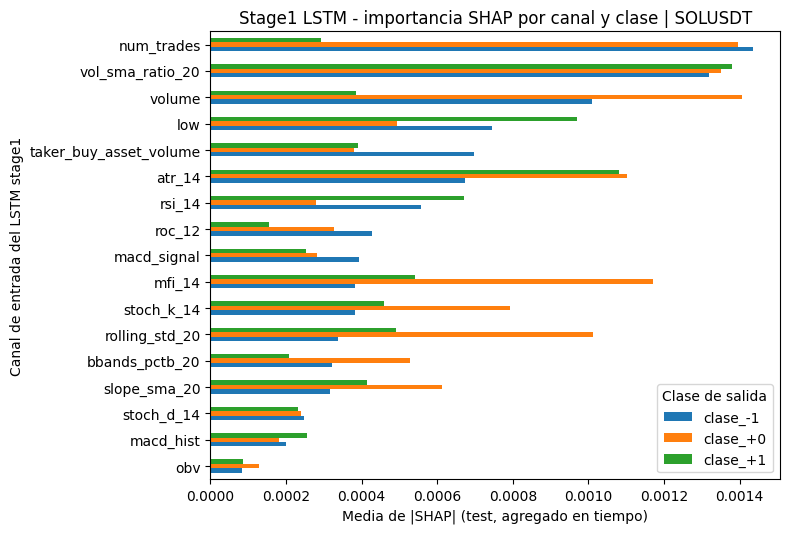

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, max(4.0, 0.32 * len(feature_channels))))
plot_df_s1 = stage1_importance_df.drop(columns="total").sort_values(by=stage1_importance_df.columns[0])
plot_df_s1.plot(kind="barh", ax=ax)
ax.set_xlabel("Media de |SHAP| (test, agregado en tiempo)")
ax.set_ylabel("Canal de entrada del LSTM stage1")
ax.set_title(f"Stage1 LSTM - importancia SHAP por canal y clase | {SYMBOL}")
ax.legend(title="Clase de salida")
plt.tight_layout()
fig.savefig(SYMBOL_REPORT_DIR / "shap_stage1_feature_importance.png", dpi=140)
plt.show()


### 3.2 Atribución temporal del stage1 (donde mira el LSTM dentro de la ventana)


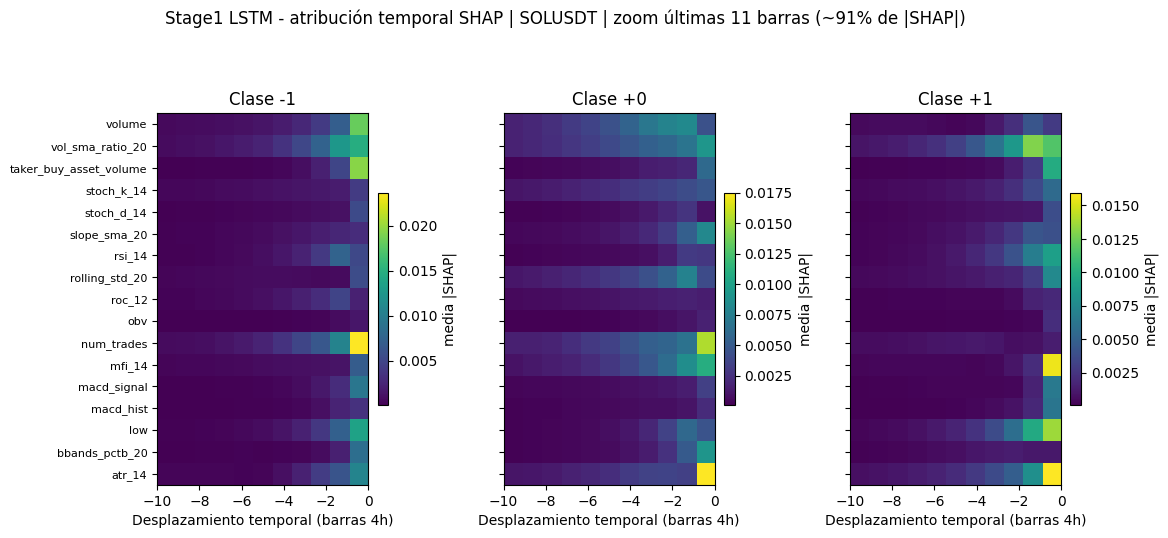

In [21]:
stage1_time_attr = {label: np.mean(np.abs(sv), axis=0) for label, sv in stage1_shap_by_class.items()}

lookback_s1 = int(handle.lookback_bars)
lag_labels_s1 = np.arange(-lookback_s1 + 1, 1)

stacked_s1 = np.stack(list(stage1_time_attr.values()), axis=0)
time_profile_s1 = np.mean(stacked_s1, axis=(0, 2))
total_mass_s1 = float(time_profile_s1.sum())
if total_mass_s1 > 0.0:
    cum_recent_s1 = np.cumsum(time_profile_s1[::-1])
    recent_bars_s1 = int(np.searchsorted(cum_recent_s1 / total_mass_s1, 0.90)) + 1
else:
    recent_bars_s1 = lookback_s1
recent_bars_s1 = int(np.clip(recent_bars_s1, min(10, lookback_s1), lookback_s1))
start_idx_s1 = lookback_s1 - recent_bars_s1
mass_pct_s1 = 100.0 * float(time_profile_s1[start_idx_s1:].sum() / max(total_mass_s1, 1e-12))
x_min_s1, x_max_s1 = int(lag_labels_s1[start_idx_s1]), 0

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, max(4.0, 0.32 * len(feature_channels))),
    sharey=True,
)
for ax, (label, mat) in zip(axes, stage1_time_attr.items()):
    mat_zoom = mat[start_idx_s1:, :]
    im = ax.imshow(
        mat_zoom.T,
        aspect="auto",
        origin="lower",
        cmap="viridis",
        extent=[x_min_s1, x_max_s1, -0.5, len(feature_channels) - 0.5],
    )
    ax.set_title(f"Clase {label:+d}")
    ax.set_xlabel("Desplazamiento temporal (barras 4h)")
    ax.set_yticks(range(len(feature_channels)))
    ax.set_yticklabels(feature_channels, fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="media |SHAP|")
fig.suptitle(
    f"Stage1 LSTM - atribución temporal SHAP | {SYMBOL} | "
    f"zoom últimas {recent_bars_s1} barras (~{mass_pct_s1:.0f}% de |SHAP|)"
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
fig.subplots_adjust(left=0.16, wspace=0.5)
fig.savefig(SYMBOL_REPORT_DIR / "shap_stage1_time_heatmap.png", dpi=140)
plt.show()



## 4. SHAP del stage2 corrector (KernelExplainer)

Nota técnica: usamos `shap.KernelExplainer` en lugar de `TreeExplainer`
porque XGBoost 3.x almacena el `base_score` como vector multi-output para
*softmax* con `num_class=3`, y el loader de SHAP 0.46 falla al parsearlo.
KernelExplainer trata `predict_proba` como caja negra, da contribuciones
SHAP por clase con la misma semántica y, con 6-16 *features* y unos
centenares de muestras, su coste es despreciable (<1 min). El
`background` se muestrea del propio *fold* de entrenamiento del corrector.


In [22]:

import matplotlib.pyplot as plt
import numpy as np

corrector_raw_proba_test = corrector.predict_proba(
    corrector_input_test.to_numpy(dtype=np.float32)
)
corrector_proba_test = align_xgb_proba(corrector, corrector_raw_proba_test)
corrector_pred_test = np.array([-1, 0, 1])[np.argmax(corrector_proba_test, axis=1)]
corrector_conf_test = corrector_proba_test.max(axis=1)
print("Corrector classes_:", getattr(corrector, "classes_", None))
print("Predicciones del corrector en test:", dict(zip(*np.unique(corrector_pred_test, return_counts=True))))

BG_SIZE = min(50, len(corrector_input_train))
N_EXPLAIN = min(120, len(corrector_input_test))
NSAMPLES = 200

explain_set = corrector_input_test.iloc[:N_EXPLAIN].reset_index(drop=True)
explanation = explain_corrector_kernel_shap(
    corrector,
    background=corrector_input_train,
    explain=explain_set,
    nsamples=NSAMPLES,
    random_state=17,
)
shap_by_class = explanation["shap_by_class"]
print("Clases SHAP:", list(shap_by_class.keys()))
print("Shape por clase:", {k: v.shape for k, v in shap_by_class.items()})


Corrector classes_: [0 1 2]
Predicciones del corrector en test: {-1: 77, 1: 103}
Clases SHAP: [-1, 0, 1]
Shape por clase: {-1: (120, 16), 0: (120, 16), 1: (120, 16)}


### 4.1 Importancia agregada por señal (corrector)


In [23]:

import pandas as pd

feature_importance = {
    label: np.mean(np.abs(sv), axis=0) for label, sv in shap_by_class.items()
}
importance_df = pd.DataFrame(feature_importance, index=corrector_feature_names)
importance_df.columns = [f"clase_{c:+d}" for c in importance_df.columns]
importance_df["total"] = importance_df.abs().sum(axis=1)
importance_df = importance_df.sort_values("total", ascending=False)
importance_df


,clase_-1,clase_+0,clase_+1,total
funding_rate_cum_3d,0.062421,0.022238,0.084251,0.168911
ls_global_ratio,0.083216,0.008566,0.077041,0.168824
oi,0.058288,0.021612,0.073115,0.153015
oi_notional_share_vs_rolling_mean,0.062505,0.012270,0.051154,0.125929
oi_value,0.049927,0.015969,0.047362,0.113257
funding_rate,0.039144,0.018810,0.046593,0.104547
oi_value_zscore_rolling,0.042408,0.009217,0.045935,0.097560
funding_rate_cum_7d,0.038092,0.009272,0.043596,0.090960
funding_rate_cum_24h,0.026696,0.019836,0.033381,0.079913
lstm_margin,0.033711,0.007060,0.031142,0.071912


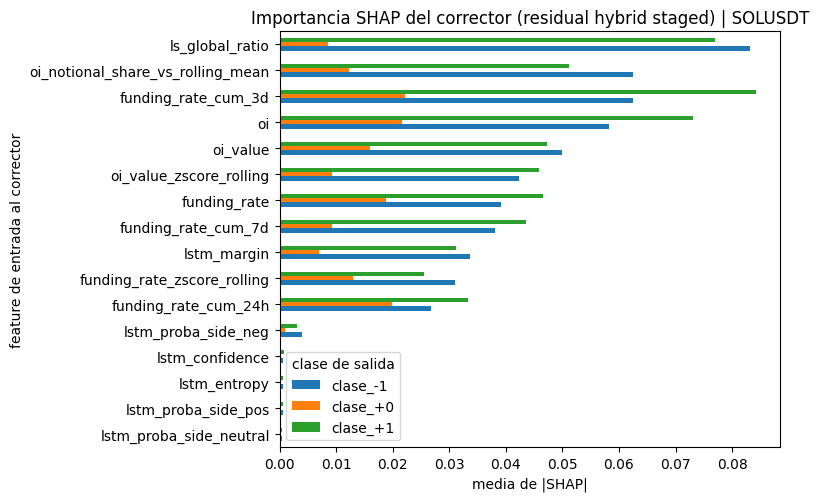

In [24]:

fig, ax = plt.subplots(figsize=(8, max(4.0, 0.32 * len(corrector_feature_names))))
plot_df = importance_df.drop(columns="total").sort_values(by=importance_df.columns[0])
plot_df.plot(kind="barh", ax=ax)
ax.set_xlabel("media de |SHAP|")
ax.set_ylabel("feature de entrada al corrector")
ax.set_title(f"Importancia SHAP del corrector (residual hybrid staged) | {SYMBOL}")
ax.legend(title="clase de salida")
plt.tight_layout()
fig.savefig(SYMBOL_REPORT_DIR / "shap_feature_importance.png", dpi=140)
plt.show()


### 4.2 Beeswarm SHAP por clase (corrector)


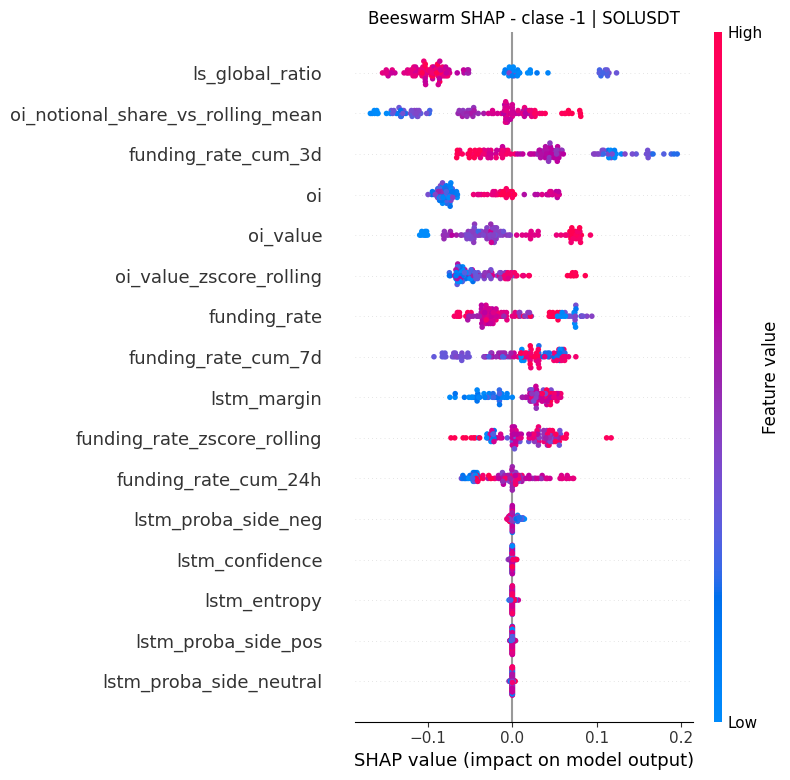

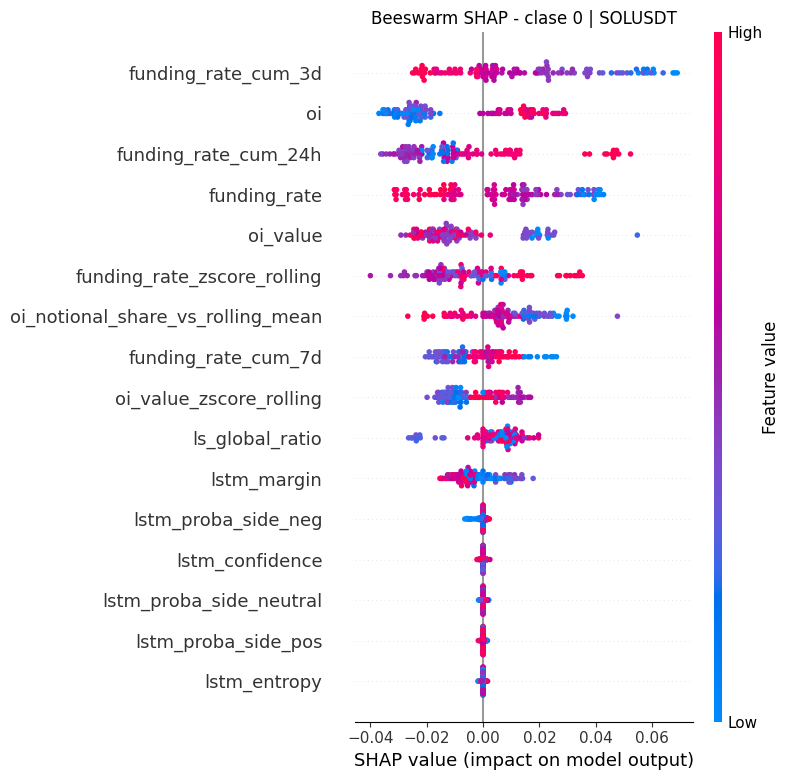

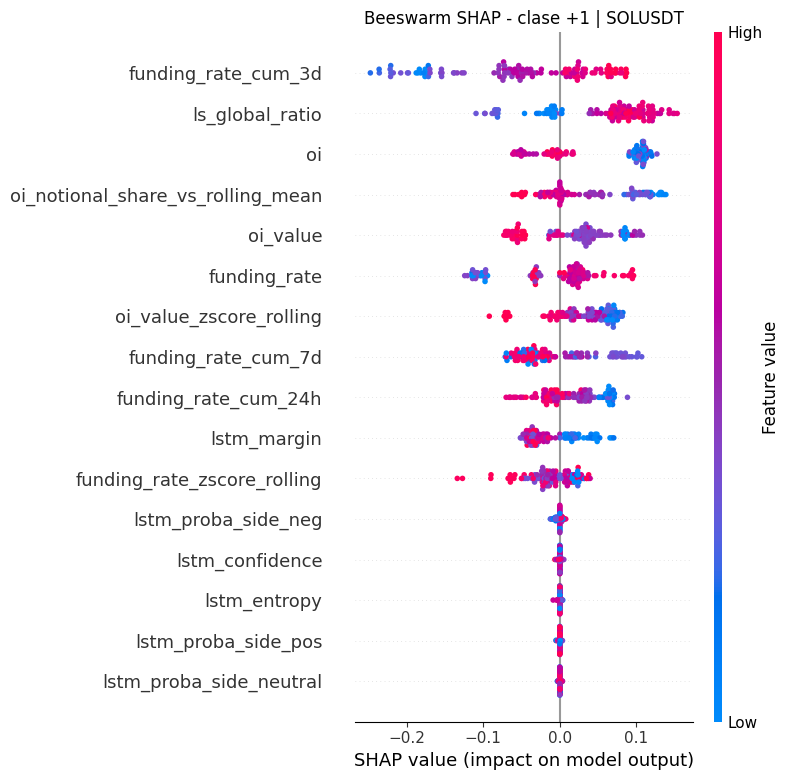

In [25]:

def _save_beeswarm(label_idx: int, label_name: str):
    import shap
    fig = plt.figure(figsize=(7, max(3.5, 0.32 * len(corrector_feature_names))))
    shap.summary_plot(
        shap_by_class[label_idx],
        explain_set,
        feature_names=corrector_feature_names,
        show=False,
    )
    plt.title(f"Beeswarm SHAP - clase {label_name} | {SYMBOL}")
    plt.tight_layout()
    out_path = SYMBOL_REPORT_DIR / (
        "shap_beeswarm_class_" + label_name.replace("+", "p").replace("-", "m") + ".png"
    )
    fig.savefig(out_path, dpi=140)
    plt.show()

for lbl, name in [(-1, "-1"), (0, "0"), (1, "+1")]:
    _save_beeswarm(lbl, name)


## 5. Persistencia de evidencias

Artefactos exportados bajo `reports/validation/explainability/solusdt/`:

- `shap_summary.json`
- `shap_stage1_feature_importance.png`, `shap_stage1_time_heatmap.png`
- `shap_feature_importance.png`
- `shap_beeswarm_class_m1.png`, `shap_beeswarm_class_0.png`, `shap_beeswarm_class_p1.png`


In [26]:

top_per_class = {}
for label in [-1, 0, 1]:
    col = f"clase_{label:+d}"
    top_per_class[str(label)] = (
        importance_df[[col]].sort_values(col, ascending=False).reset_index().rename(columns={"index": "feature", col: "mean_abs_shap"}).to_dict(orient="records")
    )

shap_summary = {
    "symbol": handle.symbol,
    "family": handle.family,
    "engine_family": handle.engine_family,
    "lane": handle.lane,
    "active_blocks_id": handle.active_blocks_id,
    "labeling_method": handle.labeling_method,
    "study_id": handle.study_id,
    "last_fold_dir": handle.last_fold_dir.relative_to(REPO_ROOT).as_posix(),
    "n_test_windows": int(corrector_input_test.shape[0]),
    "n_explained": int(explanation["n_explained"]),
    "n_background": int(explanation["background_size"]),
    "n_corrector_features": len(corrector_feature_names),
    "explainer": "KernelExplainer (predict_proba)",
    "stage1_feature_columns": list(handle.feature_channel_order),
    "stage2_feature_columns": list(corrector_feature_names),
    "corrector_base_feature_columns": list(residual_manifest.get("corrector_base_feature_columns") or []),
    "stage1_feature_importance": stage1_importance_df.to_dict(orient="index"),
    "stage1_top_features_per_class": {
        str(label): (
            stage1_importance_df[[f"clase_{label:+d}"]]
            .sort_values(f"clase_{label:+d}", ascending=False)
            .head(5)
            .reset_index()
            .rename(columns={"index": "feature", f"clase_{label:+d}": "mean_abs_shap"})
            .to_dict(orient="records")
        )
        for label in [-1, 0, 1]
    },
    "stage2_feature_importance": importance_df.to_dict(orient="index"),
    "stage2_top_features_per_class": top_per_class,
    "feature_importance": importance_df.to_dict(orient="index"),
    "top_features_per_class": top_per_class,
    "stage1_pred_class_counts": {str(k): int(v) for k, v in zip(*np.unique(np.array([-1,0,1])[np.argmax(stage1_proba_test, axis=1)], return_counts=True))},
    "stage2_pred_class_counts": {str(k): int(v) for k, v in zip(*np.unique(corrector_pred_test, return_counts=True))},
    "stage2_confidence_p50": float(np.median(corrector_conf_test)),
    "stage2_confidence_p90": float(np.quantile(corrector_conf_test, 0.9)),
}
out_path = SYMBOL_REPORT_DIR / "shap_summary.json"
out_path.write_text(json.dumps(shap_summary, indent=2, default=float), encoding="utf-8")
print("Reporte persistido en", out_path.relative_to(REPO_ROOT))


Reporte persistido en reports/validation/explainability/solusdt/shap_summary.json


## 6. Lectura cualitativa SOLUSDT (stage1 + stage2)

SOL exhibe un patrón distinto a BNB (`02_shap_bnbusdt.ipynb`) y ETH (`03_shap_ethusdt.ipynb`): el corrector **ignora** las señales `lstm_*` y decide casi exclusivamente con el bloque `derivatives_futures`. El SHAP de dos niveles documenta esa división de trabajo de forma explícita.

### Stage1 LSTM: detector de régimen técnico binario

- **Predicciones del LSTM**: -1/0/+1 = 69/0/111 (sesgo alcista, 62 % largos; sin clase neutral).
- **Magnitudes |SHAP|**: orden 1e-3, comparables a BNB y 10× menores que ETH. El LSTM tiende hacia decisiones de cola (alta confianza por clase) sin clase intermedia.
- **Top canales por clase** (stage1):
  - `+1`: `vol_sma_ratio_20`, `atr_14`, `low`, `rsi_14`, `mfi_14`.
  - `-1`: `num_trades`, `vol_sma_ratio_20`, `volume`, `low`, `taker_buy_asset_volume`.
  - `0` (no se predice): `volume`, `num_trades`, `vol_sma_ratio_20`, `mfi_14`, `atr_14`.
- **Lectura**: el LSTM usa **dos firmas distintas según la dirección**. Para largos pesa la volatilidad (`atr_14`, `vol_sma_ratio_20`) acompañada de RSI/MFI. Para cortos pesa la **microestructura del flujo de órdenes** (`num_trades`, `volume`, `taker_buy_asset_volume`). El LSTM stage1 actúa como detector de régimen: identifica si el flujo intra-barra es comprador o vendedor.

### Stage2 corrector: decisor con derivados

- **Predicciones del corrector**: -1/0/+1 = 77/0/103 (mismo signo dominante que el LSTM, ligeramente más equilibrado).
- **Confianza**: p50 = 0.56; p90 = 0.81 (más alta que ETH, especialmente en cola).
- **Top features SHAP por clase** (stage2): **ninguna señal `lstm_*` aparece en el top-5 de ninguna clase**.
  - `+1`: `funding_rate_cum_3d` (0.084), `ls_global_ratio` (0.077), `oi` (0.073), `oi_notional_share_vs_rolling_mean` (0.051), `oi_value` (0.047).
  - `-1`: `ls_global_ratio` (0.083), `oi_notional_share_vs_rolling_mean` (0.063), `funding_rate_cum_3d` (0.062), `oi` (0.058), `oi_value` (0.050).
  - `0`: `funding_rate_cum_3d` (0.022), `oi` (0.022), `funding_rate_cum_24h` (0.020), `funding_rate` (0.019), `oi_value` (0.016).
- **Lectura**: el corrector decide con **posicionamiento (long-short ratio), apertura de interés (OI) y costes de financiación (funding)**. La consistencia direccional de `funding_rate_cum_3d` y `ls_global_ratio` entre clases `+1` y `-1` confirma que estas variables operan como **indicadores de signo** (no de magnitud absoluta), lo que es consistente con la economía de futuros perpetuos de SOL.

### Cadena causal: división de trabajo entre etapas

`vol_sma_ratio_20` + `num_trades` + `volume` -> LSTM (stage1, sesgo direccional aproximado 111/69) -> seis señales `lstm_*` + 10 columnas de derivados -> corrector (stage2, refuerza/refina a 103/77). 

El stage2 SHAP muestra que el corrector **prácticamente no consulta al LSTM**: las señales `lstm_*` están dominadas por las columnas de derivados. Pero el stage1 SHAP nos enseña que el LSTM **sí tiene contenido informativo** (magnitudes del orden 1e-3 distintas de cero, top canales coherentes por clase). La lectura es: el LSTM aporta un *prior* direccional que el corrector confirma, y refina, con derivados; si el LSTM colapsara a una clase, el corrector lo notaría a través de `lstm_margin`/`lstm_entropy` (que estarían en el top), pero aquí el LSTM tiene suficiente variabilidad como para que el corrector pueda basarse en un dataset alternativo (el bloque `derivatives_futures`) sin perder información.

La promoción de SOL es el caso más claro de **inyección *staged* con bloque alternativo dominante**. Sin el stage1 SHAP, la conclusión sería el corrector ignora al LSTM y decide con derivados; con ambos niveles documentamos algo más matizado: el LSTM contribuye con un sesgo direccional que el corrector valida. La división de trabajo (LSTM = qué régimen, derivados = qué dirección) es un patrón replicable y un argumento empírico a favor de la jerarquía *greedy* que descubrió el bloque `derivatives_futures` para este símbolo.
